# New Project Testbench


Project Sturcture
- Reproduce Lia's work -> code at...
- Structurize e.g.
  - query
  - reformatting
  - saving
  - merging
  - expand

## Lia's work

In [1]:
from utils.io import load
from utils.fcts_cat_merge import get_mask_cat2_in_cat1, nearest_neighbor_distances_units
from astropy.io.ascii import read
from utils.io import Path

In [2]:
# get HPIC
hpic = read(Path().additional_data+"/HPICv1.0/full_HPIC.txt",delimiter = "|")

In [10]:
print(hpic)
print(hpic.colnames)

         star_name                ra     ... sy_planets_flag hostname
---------------------------- ----------- ... --------------- --------
               TIC 459832522  213.915338 ...               0     null
               TIC 245873777   68.980213 ...               1  alf Tau
               TIC 272314138  187.791407 ...               0     null
               TIC 322899250  101.286998 ...               0     null
               TIC 368326352   79.172437 ...               0     null
               TIC 471011144  219.903981 ...               0     null
               TIC 280310048  114.825217 ...               0     null
               TIC 471011145  219.910043 ...               0     null
               TIC 157587146  279.234764 ...               0     null
               TIC 423088367  116.328966 ...               1 HD 62509
                         ...         ... ...             ...      ...
GAIA DR3 6742328107524142976 289.8782682 ...               0     null
GAIA DR3 67455736596

In [3]:
# get starcat50
[StarCat5_50pc] = load(["catalogs/StarCat5_50pc"])

In [4]:
print(StarCat5_50pc.colnames)

['main_id', 'coo_ra', 'coo_dec', 'sptype_string', 'plx_value', 'dist_st_value', 'coo_gal_l', 'coo_gal_b', 'teff_st_value', 'teff_ref', 'mass_st_value', 'mass_ref', 'radius_st_value', 'radius_ref', 'binary_flag', 'binary_ref', 'mag_i_value', 'mag_j_value', 'class_lum', 'class_temp', 'parent_main_id', 'sep_ang_value', 'unresolved_binaries', 'ms_temp_class', 'ms_lum_class', 'mass_flag', 'higher_order_multiples', 'single_parent', 'trivial_binaries', 'sep_flag', 'sep_phys_value', 'requirement_flag', 'suitable_companions', 'stableHZ', 'ecliptic_pm45deg']


In [4]:
radius = nearest_neighbor_distances_units(StarCat5_50pc["coo_ra"],StarCat5_50pc["coo_dec"])
#strange error message, something about units but I did give right unit as requested in docstring


In [6]:
print(radius)

[1.36948670e+02 3.48331422e+03 3.62958072e+03 ... 0.00000000e+00
 1.49948267e+00 1.80393132e+03]


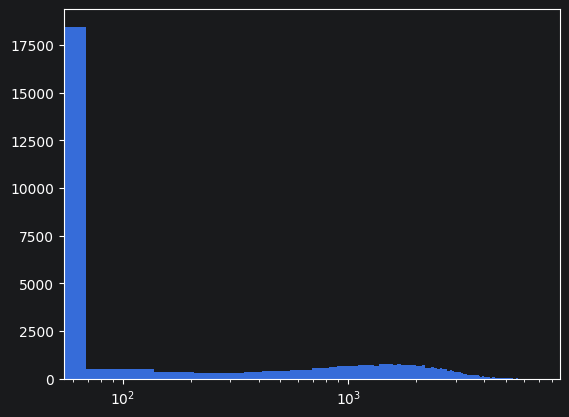

In [11]:
import matplotlib.pyplot as plt
plt.figure()
xs = [x for x in range(len(radius))]
plt.hist(radius,bins = 100)
plt.xscale('log')
plt.show()
#so did she use a single radius for all? I would have thought the farther away objects need a different one than the closer in ones
# like a star with 1pc separation is close in 1as but but farther out way fewer
# I can discuss that with her later, let's just take what this gives me
# most objects are very close by but a few have > 50 (as?) to their next neighbor

In [5]:
#I want to get hipc info and for stars not having it available get starcat info
# so I am going to mask away all stars in starcat that have hipc info
# then stack hpic together with the remaining stars from starcat
# this means for the match function that cat 1 is hpic and cat 2 starcat

# what does it mean for the radius, do I just take the rearest neighbor thing from starcat5 or do I need to reduce it?
# wait, the radius is supposed to be a float?

# match with starcat
mask_cat2_in_cat1 = get_mask_cat2_in_cat1(name_cat1 = hpic["simbad_name"],
                                          ra_cat1 = hpic["ra"],
                                          dec_cat1 = hpic["dec"],
                                          name_cat2 = StarCat5_50pc["main_id"],
                                          ra_cat2 = StarCat5_50pc["coo_ra"],
                                          dec_cat2 = StarCat5_50pc["coo_dec"],
                                          r_arcsec = radius)

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

## Input
try to query different archives outside of db context

In [3]:
from provider.utils import query

### Gaia

Notes: I could technically structurize it more (input parameters, output parameters,...) but don't think is useful at this point as not all sources will be via adql. better get list first, then write function for structuring.

In [1]:
adql_query = """
    SELECT s.source_id ,p.mass_flame, p.radius_flame,
        p.teff_gspphot, p.teff_gspspec, m.nss_solution_type, p.age_flame,
        p.teff_gspspec_lower, p.teff_gspspec_upper, p.flags_gspspec
    FROM gaiadr3.gaia_source as s
        JOIN gaiadr3.astrophysical_parameters as p ON s.source_id=p.source_id
            LEFT JOIN gaiadr3.nss_two_body_orbit as m ON s.source_id=m.source_id
    WHERE s.parallax >=30."""

gaia_helptab = query("https://gea.esac.esa.int/tap-server/tap", adql_query)

Service is UP and running.


In [2]:
print(gaia_helptab)

     source_id      mass_flame ...               flags_gspspec              
                     solMass   ...                                          
------------------- ---------- ... -----------------------------------------
    769456276704128         -- ...                                          
  56252256123908096         -- ...                                          
  60186343087140096  0.7181468 ... 00000000000001110009900001000999999999995
  73326018139806592         -- ... 00100111000009999999999999999999999999999
  78649033103283584         -- ...                                          
  98092934167683072         -- ...                                          
 115311458058061440  0.8797081 ... 00000000000001010000000109900990099999995
 115851902384016128         -- ...                                          
 126342377182577408         -- ...                                          
                ...        ... ...                                       ...

### HWO

In [ ]:
# spores see utils.analysis.create_other_catalogs
# same for HPIC
# so far both accessed via downloaded csv file. as they are not supposed to change often, I could keep it that way
# spores can be downloaded at https://sites.google.com/berkeley.edu/spores-hwo/science
# old saving location is Nebenproject/life_cat/data

## Reformatting

In [ ]:
# input table
# changes in column name
# changes in data e.g. unit


## Saving

In [ ]:
# input table (astropy? or pandas)
# output structure, so far

save(
    [table],
    ["name"],
    location="...",
)